In [1]:
import numpy as np
import healpy as hp
from pixell import enmap, curvedsky as cs
import numpy as np

In [2]:
alm = hp.read_alm("SCRATCH/reconstructed_tau_alm_00001.fits",hdu=(1)) # load reconstructed tau alm

In [3]:
inputalm = hp.read_alm("SCRATCH/tau_alm_00001.fits", hdu=(1,2,3))[0] #load input tau alm

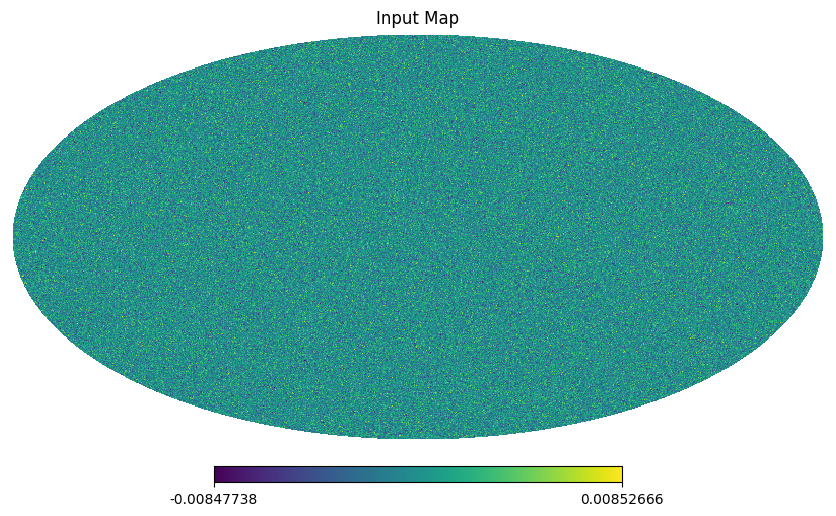

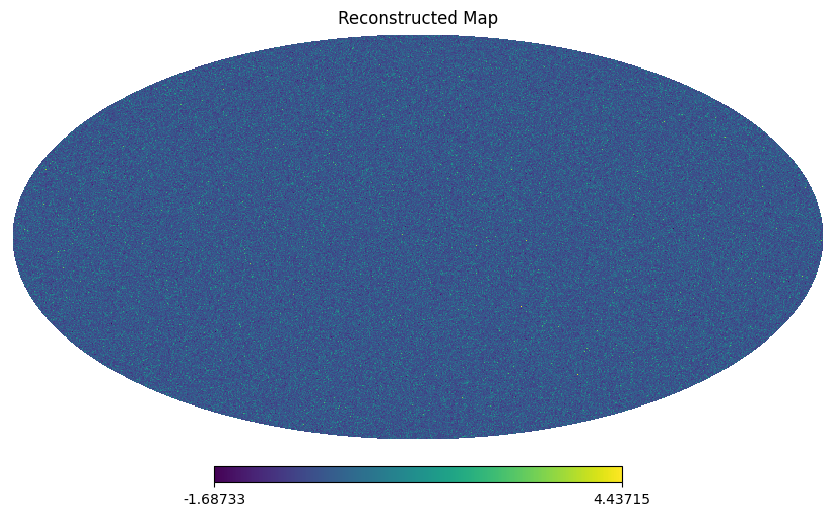

In [15]:
recon_map = hp.alm2map(alm, nside=2048)
input_map = hp.alm2map(inputalm, nside=2048)

hp.mollview(input_map, title="Input Map")
plt.savefig("SCRATCH/inputmap.png", dpi=300)
hp.mollview(recon_map, title="Reconstructed Map")
plt.savefig("SCRATCH/reconmap.png", dpi=300)

In [4]:
ps = cs.alm2cl(alm) # get the raw, noisy power spectrum of the reconstructed map
taups = cs.alm2cl(inputalm) # get the power spectrum of the tau simulation you put in
cross_ps = cs.alm2cl(alm, inputalm) # get the cross-power spectrum of the input and reconstructed signals

In [5]:
clells, cltau = np.loadtxt("cmb-screening-demo/data/cl_tau.txt", skiprows=1, unpack=True)

In [6]:

bin_edges = np.arange(0, 4000 + 1, 100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

def bin_cl(cl):
    return np.array([
        np.mean(cl[bin_edges[i]:bin_edges[i+1]])
        for i in range(len(bin_edges)-1)
    ])

/home/darbyk12/.virtualenvs/tri_scenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/darbyk12/.virtualenvs/tri_scenv/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


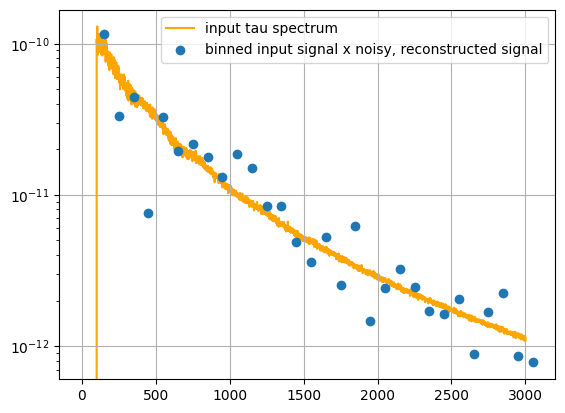

In [9]:
import matplotlib.pyplot as plt

plt.semilogy(taups, label="input tau spectrum", c="orange", zorder=0)
plt.scatter(bin_centers, -bin_cl(cross_ps), label="binned input signal x noisy, reconstructed signal",zorder=1)
plt.grid()
plt.legend()